## Personal notebook for Logistic Regression by Jenna Kiviaho

### For this notebook the cleaned_100k.csv was used. The same skeleton from the main notebook was copied to ensure the same pipeline for the results comparison.

**Workflow**
1. Importing needed libraries
2. Data reading and splitting (copied from main notebook)
3. Creating skeleton (copied from main notebook)
4. Creating method for MinMaxScaler using the same formula as skeleton has
5. Running Logistic Regression without SMOTE and scaling
6. Creating Confusion Matrix without SMOTE and scaling
7. Running the model with SMOTE and scaling (using the skeleton)
8. Testing the effect of MinMaxScaler


### Imports

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline          # NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                             ConfusionMatrixDisplay,
                             accuracy_score, f1_score)
import seaborn as sns

### Reading sampled csv and splitting data 60/20/20

In [29]:
df = pd.read_csv("cleaned_100k.csv", low_memory=False)

y = df["Attack Type"]
X = df.drop("Attack Type", axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, random_state=42, stratify=y_train_val)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (60000, 52) Val: (20000, 52) Test: (20000, 52)


### Creating skeleton

In [30]:
# ---- Agreed 10-feature list ------------------------------------------
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 5
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True):
    """Fit Pipeline+GridSearchCV and return a results dict."""
    steps = [("scaler", StandardScaler())]
    steps.append(("pca",   PCA() if use_pca else "passthrough"))
    steps.append(("smote", SMOTE(random_state=42) if use_smote else "passthrough"))
    steps.append(("clf",   clf))
    pipe = Pipeline(steps)

    grid = GridSearchCV(pipe, param_grid=param_grid,
                        cv=CV_FOLDS, scoring=SCORING,
                        n_jobs=N_JOBS, verbose=1)
    grid.fit(X_train_sel, y_train)

    y_val_pred  = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc  = accuracy_score(y_val,  y_val_pred)
    val_f1   = f1_score(y_val, y_val_pred, average="macro")
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="macro")

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{label} — test confusion matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params :", grid.best_params_)
    print(f"Val  acc={val_acc:.4f}  f1_macro={val_f1:.4f}")
    print(f"Test acc={test_acc:.4f}  f1_macro={test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label":         label,
        "best_params":   grid.best_params_,
        "val_acc":       val_acc,
        "val_f1_macro":  val_f1,
        "test_acc":      test_acc,
        "test_f1_macro": test_f1,
        "smote":         use_smote,
        "pca":           use_pca,
    }

all_results = []

### Creating minmaxscaler method

In [40]:
from sklearn.preprocessing import MinMaxScaler

# Creating method for the minmaxscaler
# Purpose is to see if it affects the results
def run_experiment_minmax(clf, param_grid, label, use_smote=True, use_pca=True):
    """Fit Pipeline+GridSearchCV and return a results dict."""
    steps = [("scaler", MinMaxScaler())]
    steps.append(("pca",   PCA() if use_pca else "passthrough"))
    steps.append(("smote", SMOTE(random_state=42) if use_smote else "passthrough"))
    steps.append(("clf",   clf))
    pipe = Pipeline(steps)

    grid = GridSearchCV(pipe, param_grid=param_grid,
                        cv=CV_FOLDS, scoring=SCORING,
                        n_jobs=N_JOBS, verbose=1)
    grid.fit(X_train_sel, y_train)

    y_val_pred  = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc  = accuracy_score(y_val,  y_val_pred)
    val_f1   = f1_score(y_val, y_val_pred, average="macro")
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="macro")

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{label} — test confusion matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params :", grid.best_params_)
    print(f"Val  acc={val_acc:.4f}  f1_macro={val_f1:.4f}")
    print(f"Test acc={test_acc:.4f}  f1_macro={test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label":         label,
        "best_params":   grid.best_params_,
        "val_acc":       val_acc,
        "val_f1_macro":  val_f1,
        "test_acc":      test_acc,
        "test_f1_macro": test_f1,
        "smote":         use_smote,
        "pca":           use_pca,
    }

### Running the model without SMOTE and scaling

In [44]:
# Running Logistic Regression without scaling and SMOTE
X_train_sel = X_train[FEATURES]

model = LogisticRegression(max_iter=3000)
model.fit(X_train_sel, y_train)

# Printing results with training data and validation data
print("Train Accuracy:", model.score(X_train_sel, y_train))
print("Val Accuracy:", model.score(X_val[FEATURES], y_val))

# Calculating F1-score
y_val_pred = model.predict(X_val[FEATURES])
f1 = f1_score(y_val, y_val_pred, average="macro")

# Printing report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

Train Accuracy: 0.85025
Val Accuracy: 0.85135

Classification Report:
                precision    recall  f1-score   support

          Bots       0.00      0.00      0.00        18
   Brute Force       0.00      0.00      0.00        75
          DDoS       0.80      0.41      0.54      1023
           DoS       0.35      0.02      0.04      1535
Normal Traffic       0.86      1.00      0.92     16616
 Port Scanning       0.00      0.00      0.00       715
   Web Attacks       0.00      0.00      0.00        18

      accuracy                           0.85     20000
     macro avg       0.29      0.20      0.21     20000
  weighted avg       0.78      0.85      0.80     20000



c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\omistaja\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\omistaja\Ap

#### **Conclusions**

Without scaling and SMOTE the model predicts 85% as "Normal Traffic", because the data is imbalanced. Also F1-macro is only 21%, which means that this model can't predict most of the Attack Types.

Max iterations were between 1000 and 3000 but the model still reached the number of iterations limit. Features have large difference in degree so this proves that StandardScaler is necessary for Logistic Regression so we can find a solution in descent amount of time.

### Creating confusion matrix without SMOTE and scaling

In [32]:
# Prediction with training data
y_train_pred = model.predict(X_train_sel)

# Creating confusion matrix (real answers vs. predictions)
cnf_matrix = metrics.confusion_matrix(y_train, y_train_pred)

print(cnf_matrix)

[[    0     0     0     0    52     0     0]
 [    0     0     0     0   227     0     0]
 [    0     0  1198   165  1706     0     0]
 [    0     0   222    99  4282     0     0]
 [    0     0   107    24 49718     0     0]
 [    0     0     0     1  2143     0     0]
 [    0     0     0     0    56     0     0]]


Text(0.5, 427.9555555555555, 'Predicted label')

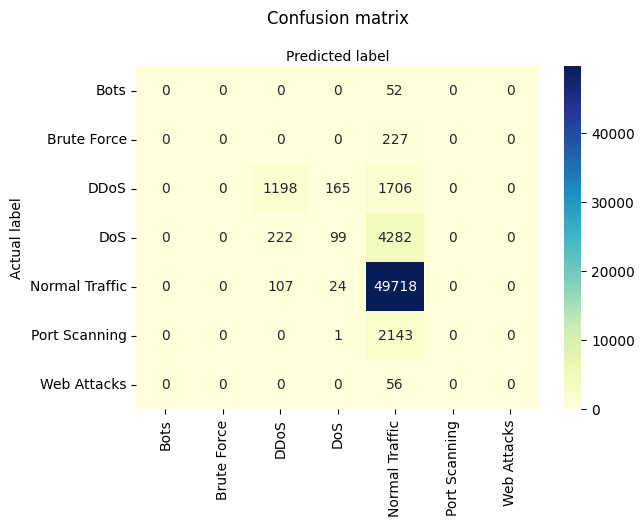

In [38]:
# Visualizing confusion matrix of prediction
class_names = np.unique(y_train)
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix, index=class_names, columns=class_names), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

#### **Conclusions**

This model without scaling and SMOTE predicts Bots, Port Scanning, Web Attacks and Brute Force mostly as Normal Traffic. The accuracy is 85% but it fails to detect 100% of Bots, Web and Brute Force attacks. This justifies the decision to use SMOTE to ensure the detection of security threats.

### Running the model with SMOTE and scaling

In this part the model uses previously created method

Fitting 5 folds for each of 6 candidates, totalling 30 fits


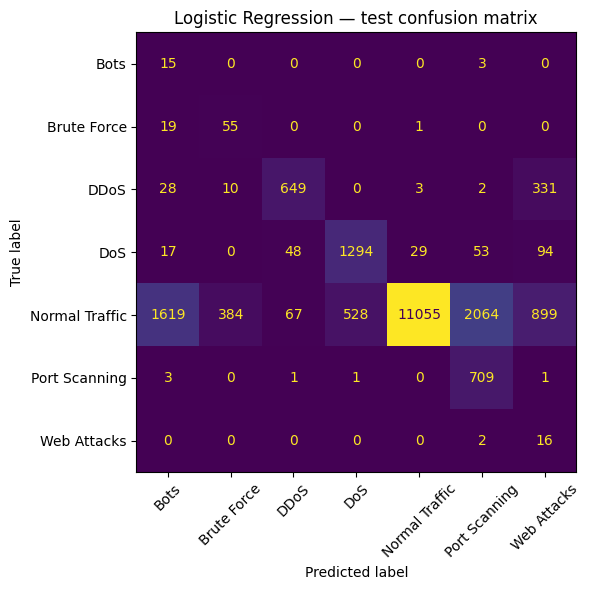


=== Logistic Regression ===
Best params : {'clf__C': 10.0, 'pca__n_components': 8}
Val  acc=0.6911  f1_macro=0.4211
Test acc=0.6896  f1_macro=0.4208
                precision    recall  f1-score   support

          Bots      0.009     0.833     0.017        18
   Brute Force      0.122     0.733     0.210        75
          DDoS      0.848     0.634     0.726      1023
           DoS      0.710     0.843     0.771      1535
Normal Traffic      0.997     0.665     0.798     16616
 Port Scanning      0.250     0.992     0.400       715
   Web Attacks      0.012     0.889     0.024        18

      accuracy                          0.690     20000
     macro avg      0.421     0.799     0.421     20000
  weighted avg      0.936     0.690     0.774     20000



In [ ]:
# Parameters
lr_params = {
    'clf__C': [0.1, 1.0, 10.0],
    'pca__n_components': [5, 8]
}

# Running test (using the function created above)
model = run_experiment(LogisticRegression(max_iter=2000, solver='lbfgs'), lr_params, "Logistic Regression")

#### **Conclusions**

Running the Logistic Regression using the skeleton which has scaling and SMOTE changed the accuracy from 85% to 69%. Even though the overall accuracy is lower, after SMOTE the model predicts around 83% of Bots and 99% of Port Scanning attacks correctly. F1-macro increased from 21% to 42% with scaling and SMOTE so this model doubled the performance.

Although with SMOTE and scaling it has false alarms and it predicts some of Normal Traffic as attacks, it is more valuable to distinguish the actual attacks more accurately for security.

### Testing the effect of MinMaxScaler

Fitting 5 folds for each of 6 candidates, totalling 30 fits


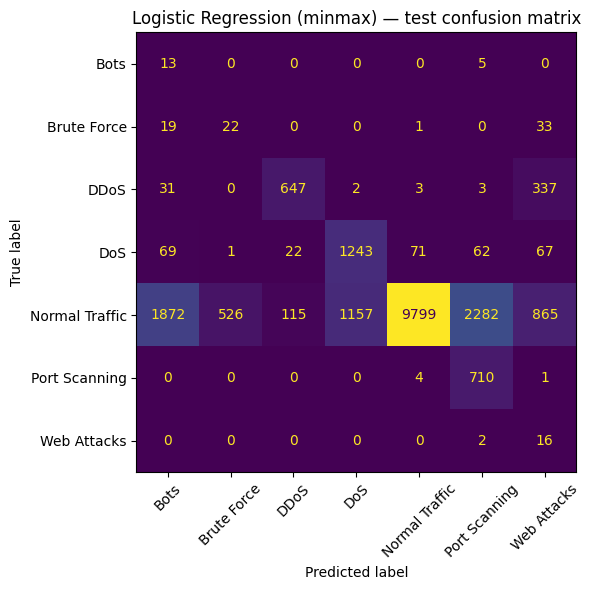


=== Logistic Regression (minmax) ===
Best params : {'clf__C': 10.0, 'pca__n_components': 8}
Val  acc=0.6267  f1_macro=0.3733
Test acc=0.6225  f1_macro=0.3672
                precision    recall  f1-score   support

          Bots      0.006     0.722     0.013        18
   Brute Force      0.040     0.293     0.071        75
          DDoS      0.825     0.632     0.716      1023
           DoS      0.517     0.810     0.631      1535
Normal Traffic      0.992     0.590     0.740     16616
 Port Scanning      0.232     0.993     0.376       715
   Web Attacks      0.012     0.889     0.024        18

      accuracy                          0.623     20000
     macro avg      0.375     0.704     0.367     20000
  weighted avg      0.915     0.623     0.713     20000



In [ ]:
# Testing with minmaxscaler (using seperately created method)
model_minmax = run_experiment_minmax(LogisticRegression(max_iter=2000, solver='lbfgs'), lr_params, "Logistic Regression (minmax)")

#### **Conclusions**

MinMaxScaler performed worse than StandardScaler. Overall accuracy decreased to around 62% when the StandardScaler had 69%. Also the recall for Brute Force and Bots decreased significantly. This is probably due to outliers and StandardScaler handles them more stable.